# ADM Error & Trace Analysis

Diagnostic analyses of the **base-model** ADM walks, split out of `llm_results.ipynb`.
All traces are pre-extracted to `Analysis/_cache/adm_traces.pkl` by
`scripts/extract_traces.py` (main + sub-ADM accepted factors, evaluated nodes,
reconstructed verdict & terminating node).

**Scope & caveats**
- Test set = 879 held-out cases, `tool_both_default`, exp-configs 1/2/3, 3 runs each.
- Terminating node is *reconstructed* from the main-ADM accepted-factor set via a fixed
  dependency order (`CRIT_YES`) — the first missing critical factor is blamed. It is not read
  from the raw execution trace.
- **Divergence** uses the only oracle runs that exist — the **TRAIN set (95 cases)**,
  `train_both_default` vs `tool_both_default`. There are no oracle runs on the test set.
- Unless stated, per-model results are shown **alongside** an aggregate rather than pooled,
  and the headline exp-config is **3 (full input)**.


In [1]:
import json, sys
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

matplotlib.rcParams['figure.dpi'] = 120

BASE  = Path('/users/sgdbareh/scratch/ADM_JURIX')
CACHE = BASE / 'Analysis' / '_cache' / 'adm_traces.pkl'
FIGS  = BASE / 'Figs'; FIGS.mkdir(exist_ok=True)

# ── Doctrine order (Yes / inventive path) + No-path short circuits ─────────────
CRIT_YES = ['DistinguishingFeatures', 'TechnicalContribution', 'Contribution',
            'Novelty', 'CandidateOTP', 'ValidOTP', 'ObjectiveTechnicalProblem',
            'OTPNotObvious', 'NonObviousOTP']
NO_SHORT = ['SecondaryIndicator', 'SufficiencyOfDisclosure']   # accepting these => verdict No
NODE_LAYER = {
    'complete_yes': 'Main', 'SecondaryIndicator': 'Main', 'SufficiencyOfDisclosure': 'Main',
    'Novelty': 'Main', 'DistinguishingFeatures': 'Main',
    'NonObviousOTP': 'Sub-ADM 2', 'OTPNotObvious': 'Sub-ADM 2', 'ValidOTP': 'Sub-ADM 2',
    'ObjectiveTechnicalProblem': 'Sub-ADM 2', 'CandidateOTP': 'Sub-ADM 1', 'Contribution': 'Sub-ADM 1',
    'TechnicalContribution': 'Sub-ADM 1', 'unknown': 'Main',
}

CFG = 3   # headline exp-config (full input) for single-config sections
MODELS       = ['GPT', 'Llama', 'Qwen']
MODEL_COLORS = {'GPT': '#1565C0', 'Llama': '#1B5E20', 'Qwen': '#B71C1C'}
AGG_COLOR    = '#37474F'

# ── Ground truth ──────────────────────────────────────────────────────────────
def _gt(fn):
    d = pd.read_pickle(BASE / 'Data' / fn)
    return d.set_index('Reference')['Outcome'].map({'Reversed': 'Yes', 'Affirmed': 'No'}).to_dict()
gt_test, gt_train = _gt('test_data_Inv_Step.pkl'), _gt('train_data_Inv_Step.pkl')

df = pd.read_pickle(CACHE)
df['gt'] = df.apply(lambda r: (gt_test if r['mode'] == 'tool' else gt_train).get(r['case']), axis=1)
df = df[df['gt'].notna()].copy()
df['correct']  = df['verdict'] == df['gt']
df['err_type'] = np.where(df['correct'], '', np.where(df['verdict'] == 'No', 'FN', 'FP'))
df['layer']    = df['term_node'].map(NODE_LAYER).fillna('Main')
df['acc_set']  = df['accepted'].apply(set)

print(f"rows={len(df)}")
print(df.groupby(['mode', 'model']).size())
print("\nTool test accuracy by model (run-level):")
print(df[df['mode']=='tool'].groupby('model')['correct'].mean().round(3))


rows=24854
mode          model
tool          GPT      7909
              Llama    7910
              Qwen     7903
train_oracle  GPT        94
              Llama      95
              Qwen       94
train_tool    GPT       284
              Llama     285
              Qwen      280
dtype: int64

Tool test accuracy by model (run-level):
model
GPT      0.548
Llama    0.534
Qwen     0.523
Name: correct, dtype: float64


## 1 — Error direction & terminating-node share  ·  per model + aggregate, **by exp-config** (run-level)

Run-level (each of the 3 runs per case counts once — no majority collapse, since case-level
barely changed the shares). Shown as a **facet across the three exp-configs** because the error
mix shifts strongly with how much input the model gets:

- **cfg1 (Appeal only)** — sparse input, little to reject on → the walk over-runs the Yes-path and
  errs at `complete_yes` (false positives).
- **cfg3 (Full)** — more to reject → errors migrate downstream to the OTP-obviousness step.

Node order is fixed by the all-config aggregate. The second row shows the **config gradient**
(aggregate error-share of the top nodes) and the **FN/FP direction** per config.


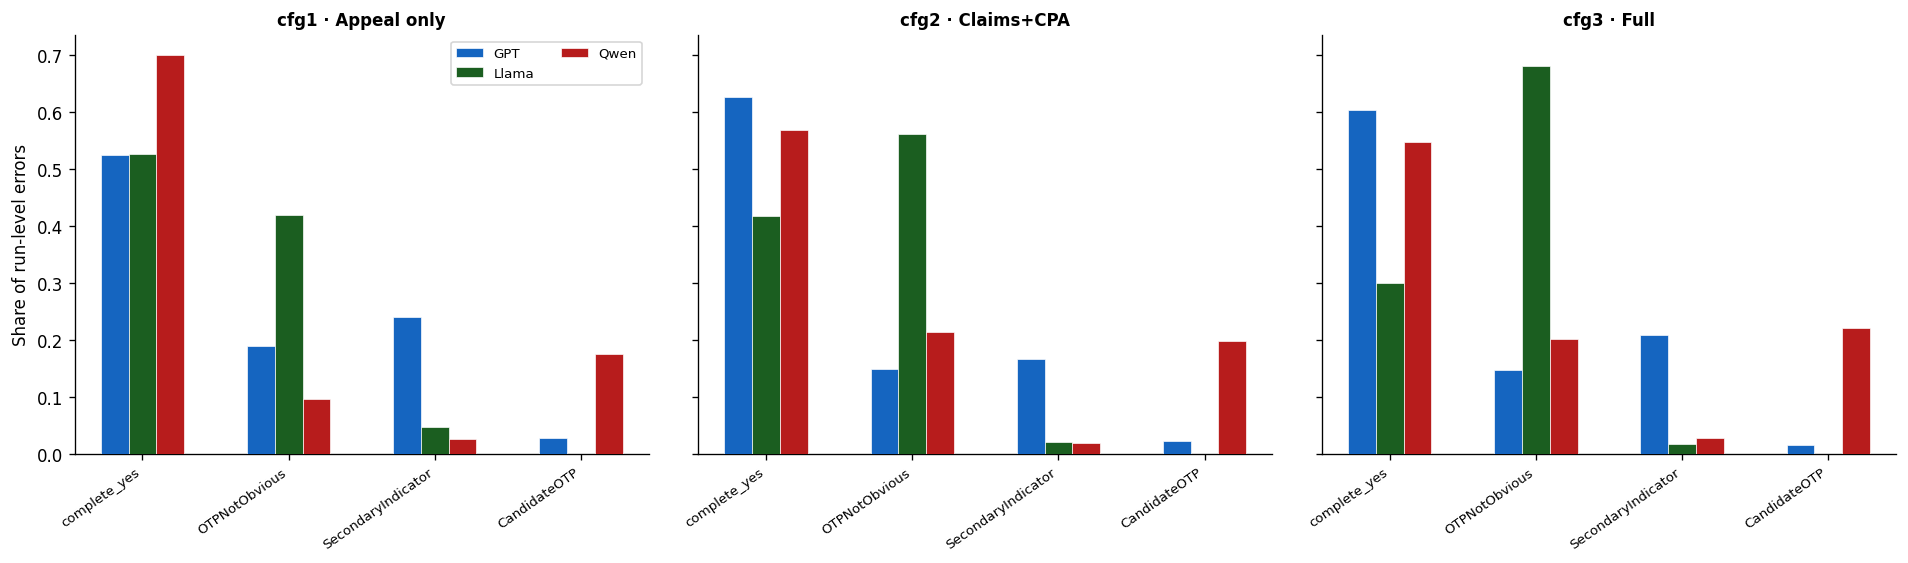

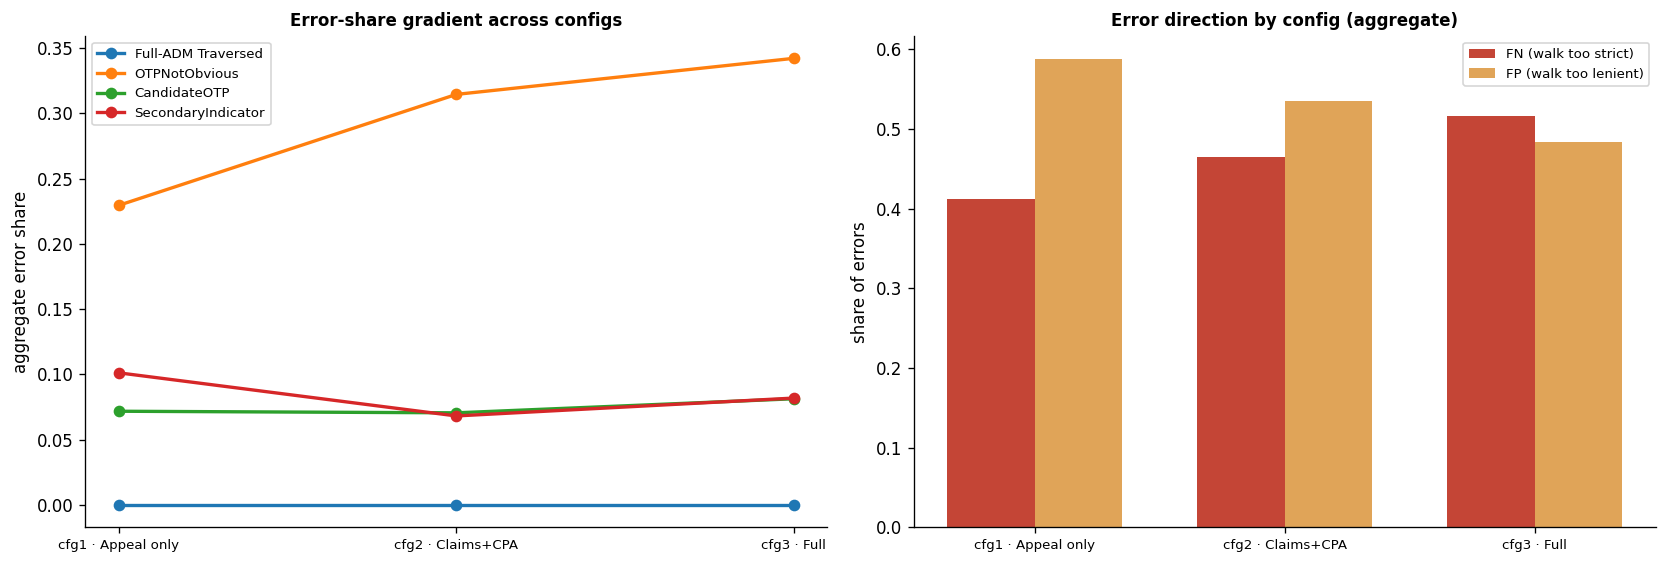

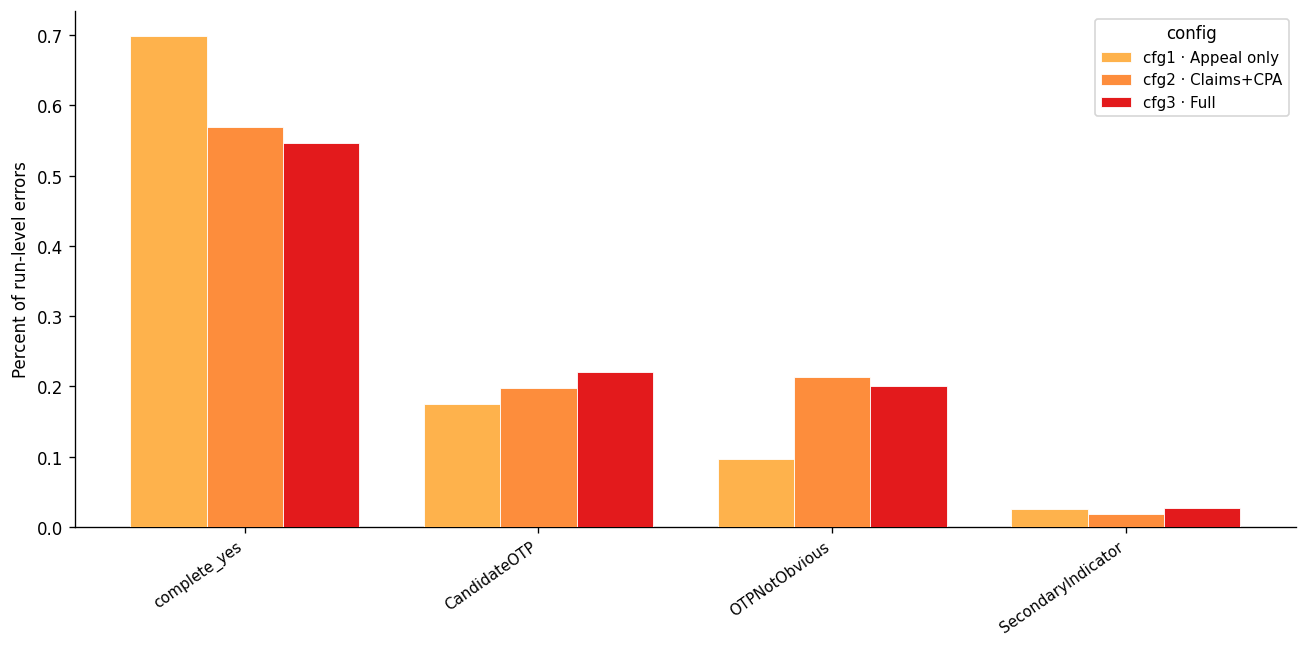

Node error-share by exp-config (run-level, aggregate):
                    cfg1 · Appeal only  cfg2 · Claims+CPA  cfg3 · Full
term_node                                                             
complete_yes                     0.587              0.535        0.483
OTPNotObvious                    0.230              0.314        0.342
SecondaryIndicator               0.101              0.068        0.082
CandidateOTP                     0.072              0.071        0.081


In [2]:
tool = df[df['mode'] == 'tool'].copy()   # run-level; correct/err_type/layer set in setup cell
CFGS = [1, 2, 3]
CFG_LBL = {1: 'cfg1 · Appeal only', 2: 'cfg2 · Claims+CPA', 3: 'cfg3 · Full'}

def share_by_node(sub):
    e = sub[~sub['correct']]
    if len(e) == 0: return pd.Series(dtype=float)
    return e['term_node'].value_counts() / len(e)

all_share = share_by_node(tool)
order = [n for n in all_share.sort_values(ascending=False).index if all_share[n] >= 0.02][:7]

# ── Facet: node error-share per config, per model + aggregate ──────────────────
x = np.arange(len(order)); wsm, wagg = 0.19, 0.30
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, cfg in zip(axes, CFGS):
    sub = tool[tool['exp_cfg'] == cfg]
    shares = {m: share_by_node(sub[sub['model'] == m]) for m in MODELS}
    for g in MODELS:
        off = {'GPT': -wsm, 'Llama': 0.0, 'Qwen': wsm}[g]
        vals = [shares[g].get(n, 0) for n in order]
        ax.bar(x + off, vals, wsm, label=g, color=MODEL_COLORS[g], edgecolor='white', linewidth=0.4, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=35, ha='right', fontsize=8)
    ax.set_title(CFG_LBL[cfg], fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Share of run-level errors'); axes[0].legend(fontsize=8, ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.savefig(FIGS / 'err1_node_share_by_cfg.png', bbox_inches='tight', dpi=150); plt.show()

# ── Config gradient + FN/FP direction ─────────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.8))
grad_nodes = ['Full-ADM Traversed', 'OTPNotObvious', 'CandidateOTP', 'SecondaryIndicator']
for n in grad_nodes:
    ys = [share_by_node(tool[tool['exp_cfg'] == c]).get(n, 0) for c in CFGS]
    axL.plot(CFGS, ys, marker='o', lw=2, label=n)
axL.set_xticks(CFGS); axL.set_xticklabels([CFG_LBL[c] for c in CFGS], fontsize=8)
axL.set_ylabel('aggregate error share'); axL.set_title('Error-share gradient across configs', fontsize=10, fontweight='bold')
axL.legend(fontsize=8); axL.spines[['top', 'right']].set_visible(False)

dir_rows = []
for c in CFGS:
    e = tool[(tool['exp_cfg'] == c) & (~tool['correct'])]; nn = len(e)
    dir_rows.append(dict(cfg=c, FN=(e['err_type'] == 'FN').sum()/nn, FP=(e['err_type'] == 'FP').sum()/nn))
dd = pd.DataFrame(dir_rows).set_index('cfg')
xc = np.arange(len(CFGS)); w = 0.35
axR.bar(xc - w/2, dd['FN'], w, label='FN (walk too strict)', color='#c44536')
axR.bar(xc + w/2, dd['FP'], w, label='FP (walk too lenient)', color='#e0a458')
axR.set_xticks(xc); axR.set_xticklabels([CFG_LBL[c] for c in CFGS], fontsize=8)
axR.set_ylabel('share of errors'); axR.set_title('Error direction by config (aggregate)', fontsize=10, fontweight='bold')
axR.legend(fontsize=8); axR.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGS / 'err1_config_gradient.png', bbox_inches='tight', dpi=150); plt.show()

# ── Qwen only: top error nodes coloured by exp-config (YlOrRd light→dark) ──────
CFG_C = {1: '#FEB24C', 2: '#FD8D3C', 3: '#E31A1C'}
qw = tool[tool['model'] == 'Qwen']
qshare = {c: share_by_node(qw[qw['exp_cfg'] == c]) for c in CFGS}
qall = share_by_node(qw)
qorder = [n for n in qall.sort_values(ascending=False).index if qall[n] >= 0.02][:7]
xq = np.arange(len(qorder)); wq = 0.26
fig, ax = plt.subplots(figsize=(11, 5.5))
for k, c in enumerate(CFGS):
    vals = [qshare[c].get(n, 0) for n in qorder]
    ax.bar(xq + (k - 1)*wq, vals, wq, label=CFG_LBL[c], color=CFG_C[c],
           edgecolor='white', linewidth=0.5, zorder=3)
ax.set_xticks(xq); ax.set_xticklabels(qorder, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Percent of run-level errors')
ax.legend(fontsize=9, title='config'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGS / 'err1_qwen_nodes_by_cfg.png', bbox_inches='tight', dpi=150); plt.show()

# ── Table: node error-share by config ─────────────────────────────────────────
tbl = pd.DataFrame({CFG_LBL[c]: share_by_node(tool[tool['exp_cfg'] == c]).reindex(order) for c in CFGS}).round(3)
print('Node error-share by exp-config (run-level, aggregate):'); print(tbl.fillna(0))


## 1b — Error direction (FN/FP) by config:  baseline vs tool  (test set)

Standard **false-negative rate** (missed *Yes* among true *Yes*) and **false-positive rate**
(false *Yes* among true *No*) for both prompting modes across the three input configs.
Baseline = LLM answers *Yes/No* directly (no ADM walk); tool = full ADM walk. Points are the
mean over the 3 models × 3 runs with 95% CI. Verdicts come from
`Analysis/_cache/verdicts.pkl` (the `results_main_<mode>_config<N>` files).


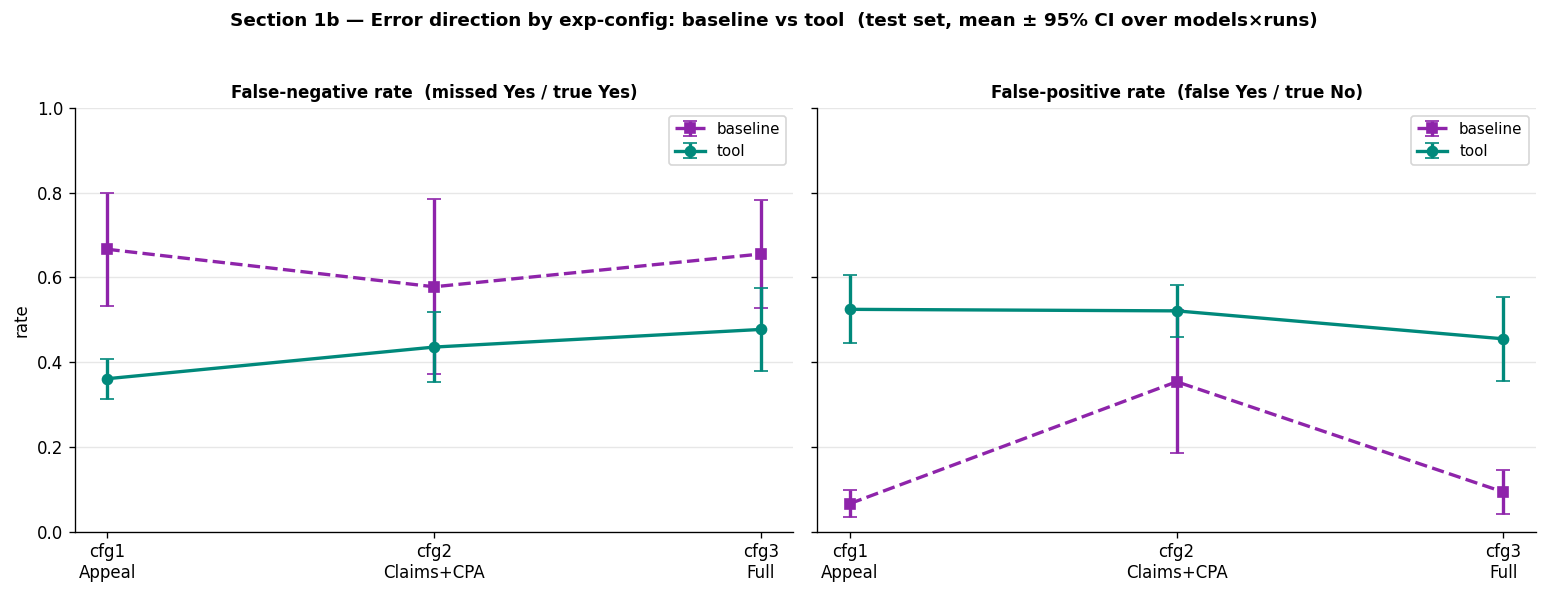

FNR / FPR by mode × config (mean over models×runs):
                    FNR    FPR
mode     exp_cfg              
baseline 1        0.666  0.066
         2        0.578  0.354
         3        0.655  0.093
tool     1        0.361  0.525
         2        0.436  0.521
         3        0.477  0.455


In [3]:
from scipy import stats as _sp

vdf = pd.read_pickle(BASE / 'Analysis' / '_cache' / 'verdicts.pkl')
vdf['gt'] = vdf['case'].map(gt_test)
vdf = vdf[vdf['gt'].notna()].copy()

def _rates(g):
    yes = g['gt'] == 'Yes'; no = ~yes
    fnr = ((g['verdict'] == 'No')  & yes).sum() / max(yes.sum(), 1)
    fpr = ((g['verdict'] == 'Yes') & no ).sum() / max(no.sum(),  1)
    return pd.Series({'FNR': fnr, 'FPR': fpr})

cell = (vdf.groupby(['model', 'mode', 'exp_cfg', 'run'])[['gt', 'verdict']]
           .apply(_rates).reset_index())

def _mci(vals):
    vals = np.asarray(vals, float)
    m = vals.mean()
    e = _sp.sem(vals) * _sp.t.ppf(0.975, len(vals) - 1) if len(vals) > 1 else 0.0
    return m, e

STYLE = {'baseline': dict(color='#8E24AA', marker='s', ls='--', lw=2),
         'tool':     dict(color='#00897B', marker='o', ls='-',  lw=2)}
fig, (axFN, axFP) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, metric, title in [(axFN, 'FNR', 'False-negative rate  (missed Yes / true Yes)'),
                          (axFP, 'FPR', 'False-positive rate  (false Yes / true No)')]:
    for mode in ['baseline', 'tool']:
        ms, es = [], []
        for c in [1, 2, 3]:
            m, e = _mci(cell[(cell['mode'] == mode) & (cell['exp_cfg'] == c)][metric].values)
            ms.append(m); es.append(e)
        ax.errorbar([1, 2, 3], ms, yerr=es, capsize=4, label=mode, **STYLE[mode])
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['cfg1\nAppeal', 'cfg2\nClaims+CPA', 'cfg3\nFull'])
    ax.set_title(title, fontsize=10, fontweight='bold'); ax.set_ylim(0, 1)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.spines[['top', 'right']].set_visible(False)
axFN.set_ylabel('rate')
fig.suptitle('Section 1b — Error direction by exp-config: baseline vs tool  (test set, mean ± 95% CI over models×runs)',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.savefig(FIGS / 'err1b_fnfp_by_config.png', bbox_inches='tight', dpi=150); plt.show()

print('FNR / FPR by mode × config (mean over models×runs):')
print(cell.groupby(['mode', 'exp_cfg'])[['FNR', 'FPR']].mean().round(3))


## 1c — Precision & Recall by config, per model:  baseline vs tool  (test set)

1b-style line panels, now **split by model**. Rows = precision (top) / recall (bottom);
columns = GPT · Llama · Qwen. Within each panel, baseline vs tool across the three
input configs. Per-model points are mean ± 95% CI over 3 runs.


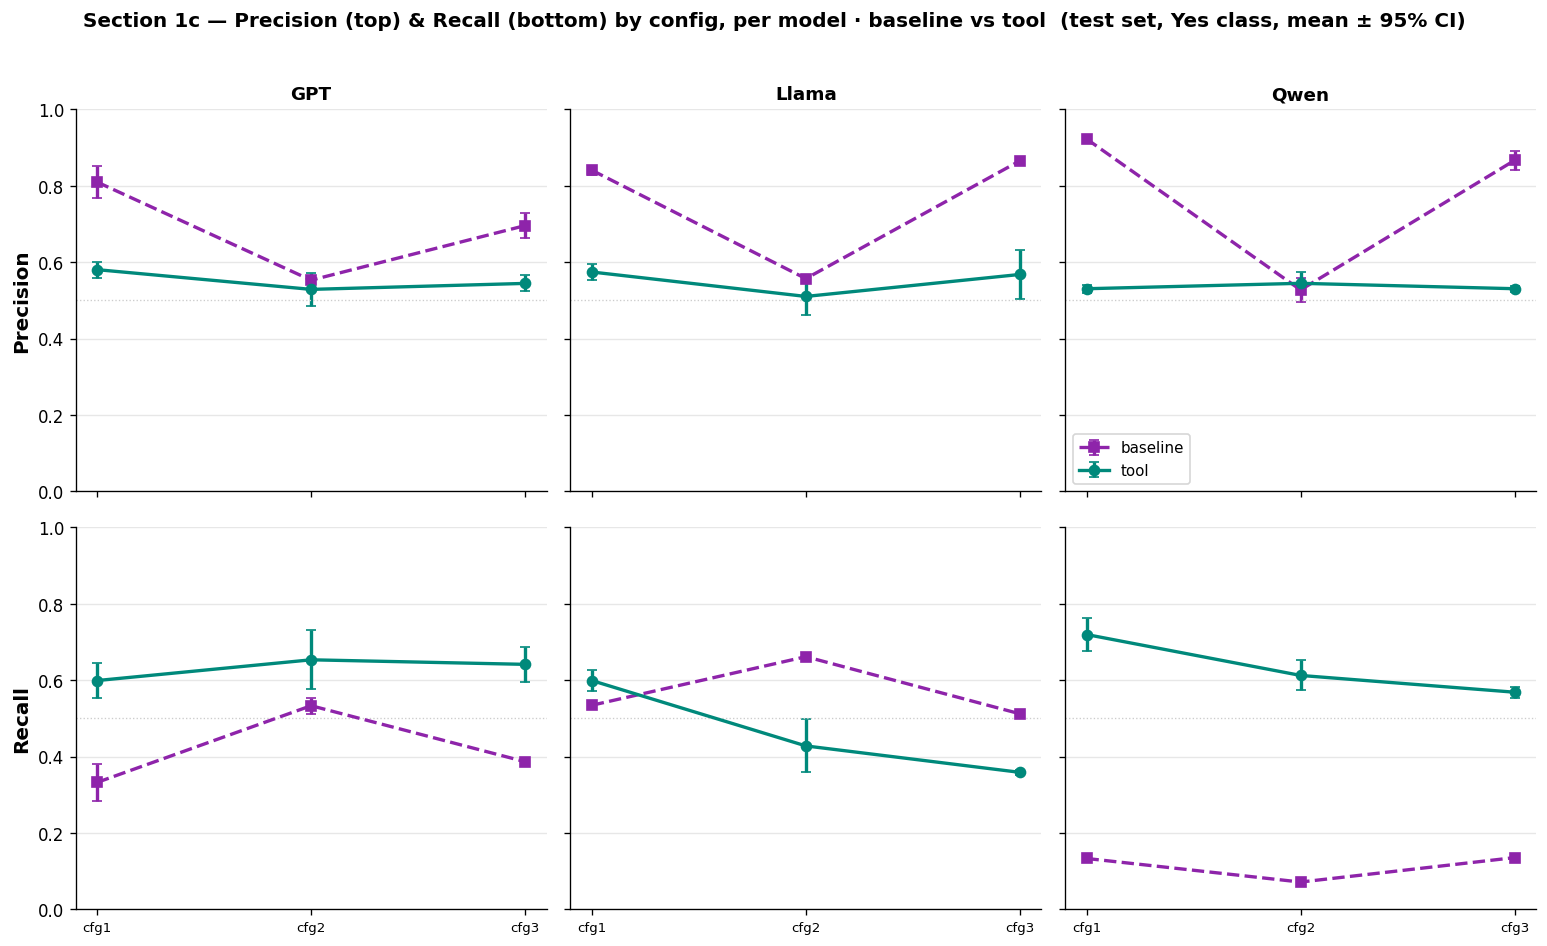

In [4]:
vdf_pr = pd.read_pickle(BASE / 'Analysis' / '_cache' / 'verdicts.pkl')
vdf_pr['gt'] = vdf_pr['case'].map(gt_test)
vdf_pr = vdf_pr[vdf_pr['gt'].notna() & vdf_pr['verdict'].isin(['Yes', 'No'])].copy()

def _pr(g):
    tp = ((g['verdict']=='Yes') & (g['gt']=='Yes')).sum()
    fp = ((g['verdict']=='Yes') & (g['gt']=='No')).sum()
    fn = ((g['verdict']=='No')  & (g['gt']=='Yes')).sum()
    return pd.Series({'P': tp/(tp+fp) if tp+fp else np.nan, 'R': tp/(tp+fn) if tp+fn else np.nan})

prcell = vdf_pr.groupby(['model', 'mode', 'exp_cfg', 'run'])[['gt', 'verdict']].apply(_pr).reset_index()

def _mci(vals):
    vals = np.asarray(vals, float); n = np.sum(~np.isnan(vals))
    m = np.nanmean(vals) if n else np.nan
    e = _sp.sem(vals, nan_policy='omit') * _sp.t.ppf(0.975, n - 1) if n > 1 else 0.0
    return m, e

STYLE = {'baseline': dict(color='#8E24AA', marker='s', ls='--', lw=2),
         'tool':     dict(color='#00897B', marker='o', ls='-',  lw=2)}
COLS = MODELS
fig, axes = plt.subplots(2, len(COLS), figsize=(13, 8), sharey=True, sharex=True)
for ri, (metric, mlab) in enumerate([('P', 'Precision'), ('R', 'Recall')]):
    for ci, model in enumerate(COLS):
        ax = axes[ri][ci]
        for mode in ['baseline', 'tool']:
            ms, es = [], []
            for c in [1, 2, 3]:
                sel = prcell[(prcell['mode'] == mode) & (prcell['exp_cfg'] == c)]
                if model != 'ALL':
                    sel = sel[sel['model'] == model]
                m, e = _mci(sel[metric].values)
                ms.append(m); es.append(e)
            ax.errorbar([1, 2, 3], ms, yerr=es, capsize=3, label=mode, **STYLE[mode])
        ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3); ax.spines[['top', 'right']].set_visible(False)
        ax.axhline(0.5, color='#ccc', ls=':', lw=0.8)
        ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['cfg1', 'cfg2', 'cfg3'], fontsize=8)
        if ri == 0: ax.set_title(model, fontsize=11, fontweight='bold')
        if ci == 0: ax.set_ylabel(mlab, fontsize=12, fontweight='bold')
axes[0][-1].legend(fontsize=9, loc='lower left')
fig.suptitle('Section 1c — Precision (top) & Recall (bottom) by config, per model · baseline vs tool  (test set, Yes class, mean ± 95% CI)',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.savefig(FIGS / 'err1c_precision_recall.png', bbox_inches='tight', dpi=150); plt.show()


## 2 — Node traffic:  how often each factor is accepted across the corpus

"Traffic" = fraction of runs in which a node appears in the main-ADM **accepted** set
(`tool`, exp-config 3). Shown per model + aggregate as bars, then painted onto the ADM graph
(darker = more traffic) — the headline-figure treatment.


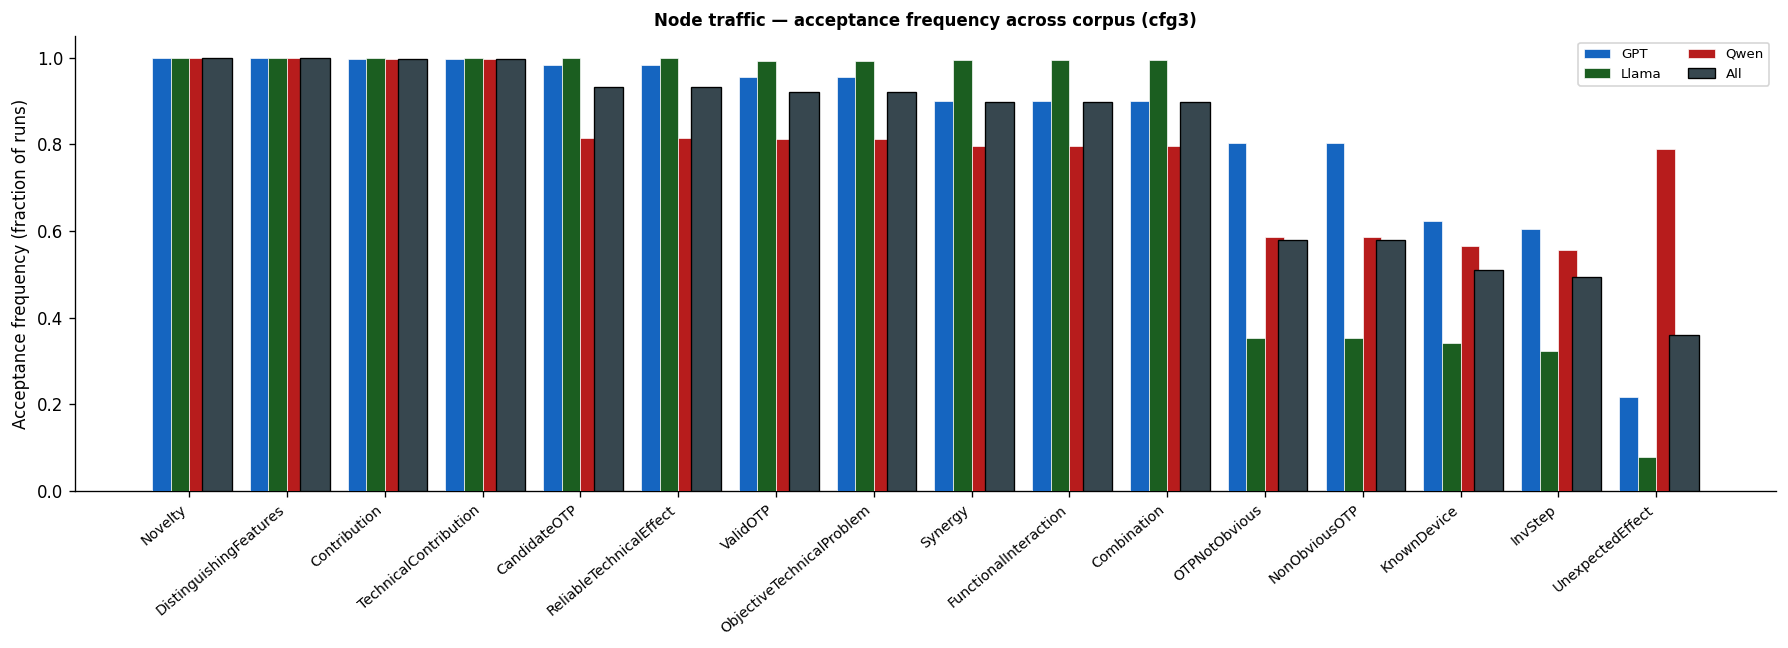

In [5]:
tool3 = df[(df['mode'] == 'tool') & (df['exp_cfg'] == CFG)]

def node_traffic(sub):
    n = len(sub)
    c = Counter()
    for s in sub['acc_set']:
        c.update(s)
    return {k: v / n for k, v in c.items()}

traf = {m: node_traffic(tool3[tool3['model'] == m]) for m in MODELS}
traf['All'] = node_traffic(tool3)

top = sorted(traf['All'], key=traf['All'].get, reverse=True)
top = [n for n in top if traf['All'][n] >= 0.05][:16]

x = np.arange(len(top)); wsm, wagg = 0.19, 0.30
fig, ax = plt.subplots(figsize=(15, 5.5))
for gname in MODELS + ['All']:
    vals = [traf[gname].get(n, 0) for n in top]
    if gname == 'All':
        ax.bar(x + 1.5*wsm, vals, wagg, label='All', color=AGG_COLOR, edgecolor='black', linewidth=0.8, zorder=3)
    else:
        off = {'GPT': -1.5*wsm, 'Llama': -0.5*wsm, 'Qwen': 0.5*wsm}[gname]
        ax.bar(x + off, vals, wsm, label=gname, color=MODEL_COLORS[gname], edgecolor='white', linewidth=0.4, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(top, rotation=40, ha='right', fontsize=8.5)
ax.set_ylabel('Acceptance frequency (fraction of runs)')
ax.set_title(f'Node traffic — acceptance frequency across corpus (cfg{CFG})', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGS / 'err2_node_traffic_bars.png', bbox_inches='tight', dpi=150); plt.show()


wrote err2_adm_traffic_main.svg   (max traffic = 100%)


/tmp/ipykernel_36921/4047169750.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlOrRd')


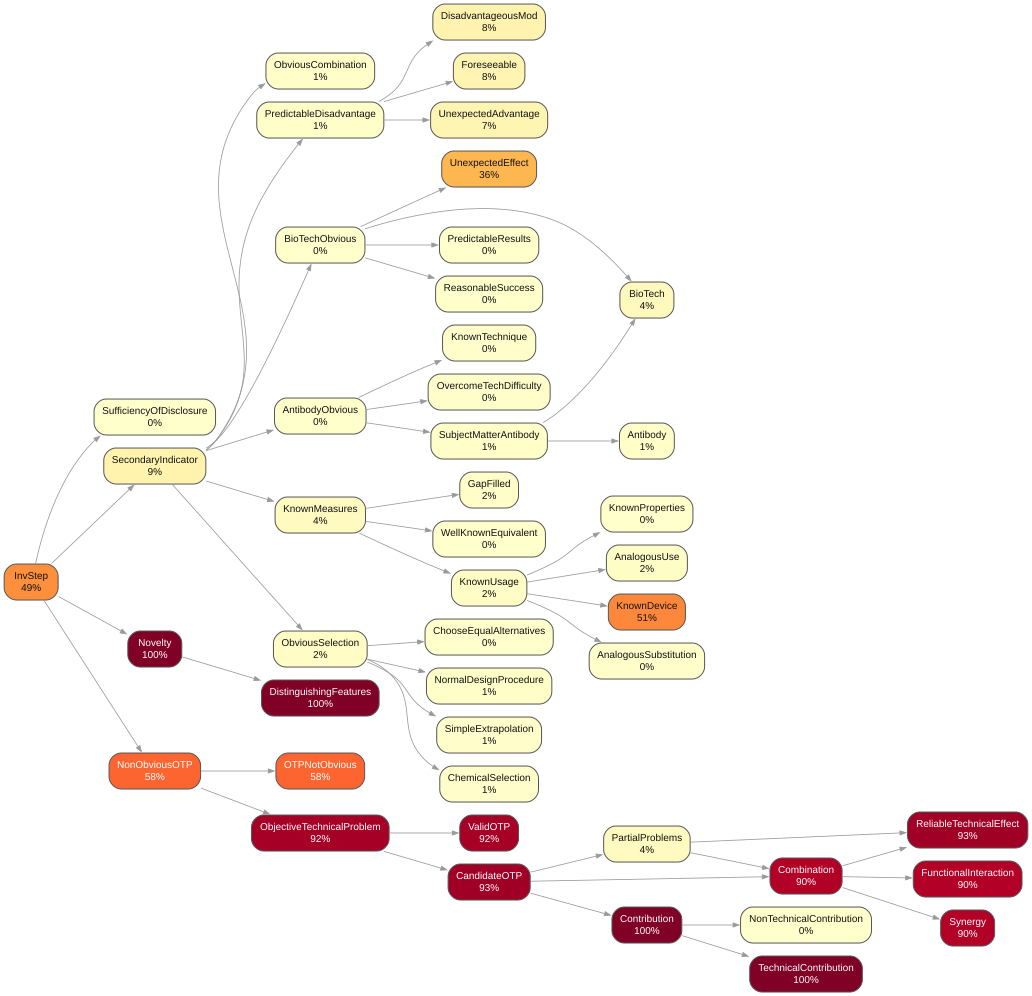

In [6]:
# ── Paint acceptance traffic onto the main ADM graph ──────────────────────────
import importlib.util, matplotlib.cm as cm
from matplotlib.colors import to_hex, Normalize
import pydot, subprocess, shutil

spec = importlib.util.spec_from_file_location('cam', BASE / 'Analysis' / 'compact_adm_map.py')
cam = importlib.util.module_from_spec(spec); spec.loader.exec_module(cam)

adm = cam.adm_main(True, True)
freq = traf['All']
vals = [freq.get(n, 0) for n in adm.nodes]
norm = Normalize(vmin=0, vmax=max(vals) if vals else 1)
cmap = cm.get_cmap('YlOrRd')

g = pydot.Dot(graph_type='digraph', rankdir='LR', nodesep='0.18', ranksep='0.5', bgcolor='white')
g.set_node_defaults(shape='box', style='rounded,filled', fontname='Arial', fontsize='10')
for name, node in adm.nodes.items():
    f = freq.get(name, 0.0)
    fill = to_hex(cmap(norm(f)))
    fontcolor = 'white' if norm(f) > 0.55 else '#111111'
    g.add_node(pydot.Node(name, label=f'{name}\n{f:.0%}', fillcolor=fill, fontcolor=fontcolor, color='#555555'))
for name, node in adm.nodes.items():
    for child in getattr(node, 'children', None) or []:
        if child in adm.nodes:
            g.add_edge(pydot.Edge(name, child, color='#999999', arrowsize='0.6', penwidth='0.8'))

svg_path = FIGS / 'err2_adm_traffic_main.svg'
g.write(str(svg_path), format='svg')   # this graphviz build has no PNG backend; SVG only
print('wrote', svg_path.name, '  (max traffic = %.0f%%)' % (max(vals) * 100))

from IPython.display import SVG, display
display(SVG(filename=str(svg_path)))


## 3 — Path frequency:  common doctrinal routes, coloured by correctness

Each run is reduced to a **path signature**: the accepted prefix along the Yes-path
(`CRIT_YES`) up to the first missing critical factor (the terminus), or a No-path
short-circuit (`SecondaryIndicator` / `SufficiencyOfDisclosure`). The most common paths are
ranked with the fraction of runs on that path that were **correct**.


/tmp/ipykernel_36921/2261202262.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('RdYlGn')(topN['correct'].values)


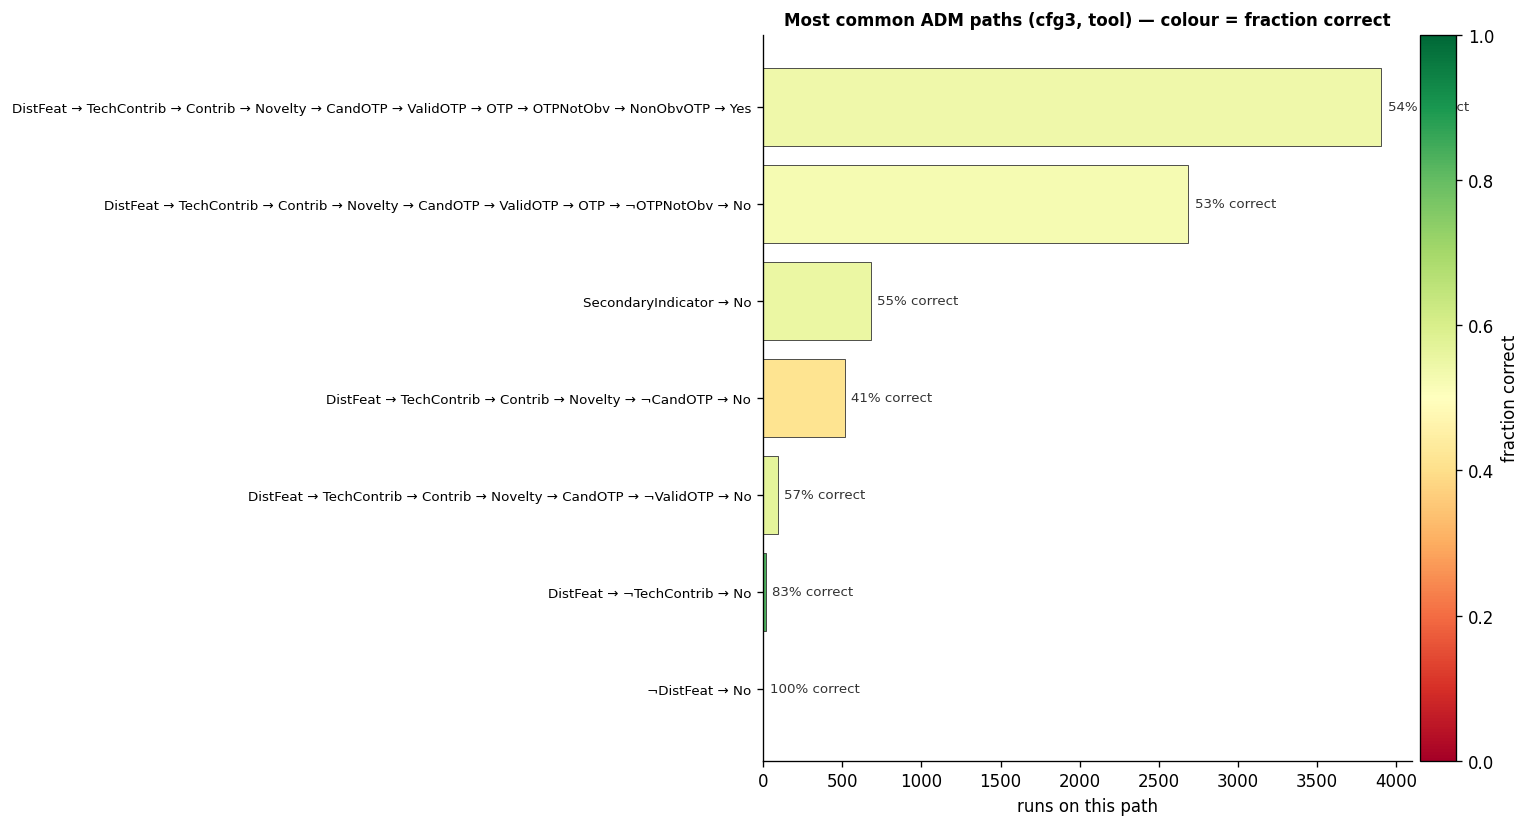

                                                    runs  correct
sig                                                              
DistFeat → TechContrib → Contrib → Novelty → Ca...  3906    0.539
DistFeat → TechContrib → Contrib → Novelty → Ca...  2687    0.526
SecondaryIndicator → No                              683    0.553
DistFeat → TechContrib → Contrib → Novelty → ¬C...   517    0.414
DistFeat → TechContrib → Contrib → Novelty → Ca...    93    0.570
DistFeat → ¬TechContrib → No                          18    0.833
¬DistFeat → No                                         2    1.000


In [7]:
SHORT = {'DistinguishingFeatures':'DistFeat','TechnicalContribution':'TechContrib','Contribution':'Contrib',
         'Novelty':'Novelty','CandidateOTP':'CandOTP','ValidOTP':'ValidOTP',
         'ObjectiveTechnicalProblem':'OTP','OTPNotObvious':'OTPNotObv','NonObviousOTP':'NonObvOTP'}

def path_sig(acc):
    s = set(acc)
    for sc in NO_SHORT:
        if sc in s:
            return f'{sc} → No'
    parts = []
    for f in CRIT_YES:
        if f in s:
            parts.append(SHORT[f])
        else:
            parts.append('¬' + SHORT[f]); return ' → '.join(parts) + ' → No'
    return ' → '.join(parts) + ' → Yes'

p = tool3.copy()
p['sig'] = p['accepted'].apply(path_sig)
agg = (p.groupby('sig')
         .agg(runs=('correct', 'size'), correct=('correct', 'mean'))
         .sort_values('runs', ascending=False))
topN = agg.head(14)[::-1]

fig, ax = plt.subplots(figsize=(13, 7))
colors = cm.get_cmap('RdYlGn')(topN['correct'].values)
ax.barh(range(len(topN)), topN['runs'].values, color=colors, edgecolor='#333', linewidth=0.5)
for i, (runs, cor) in enumerate(zip(topN['runs'], topN['correct'])):
    ax.text(runs + max(topN['runs'])*0.01, i, f'{cor:.0%} correct', va='center', fontsize=8, color='#333')
ax.set_yticks(range(len(topN))); ax.set_yticklabels(topN.index, fontsize=8)
ax.set_xlabel('runs on this path'); ax.set_title(f'Most common ADM paths (cfg{CFG}, tool) — colour = fraction correct', fontsize=10, fontweight='bold')
sm = cm.ScalarMappable(cmap='RdYlGn', norm=Normalize(0, 1)); sm.set_array([])
fig.colorbar(sm, ax=ax, label='fraction correct', pad=0.01)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGS / 'err3_path_frequency.png', bbox_inches='tight', dpi=150); plt.show()
print(agg.head(14).round(3))


## 4 — Divergence:  where the tool walk departs from the oracle  (TRAIN set)

The only oracle traces are on the **95-case train set** (`train_both_default`). For each
(model, case) we build the case-level accepted set (factor accepted in ≥2 of 3 runs) in both
**tool** and **oracle** mode, then find the **first node** (canonical order = No-shortcuts →
`CRIT_YES`) whose membership disagrees. That first-divergence node is where, absent oracle
guidance, the model's doctrinal walk first goes off-script — and we flag whether it flips the verdict.


train cases matched (model,case) in both tool & oracle: 283

verdict flip rate tool vs oracle: 42.4%


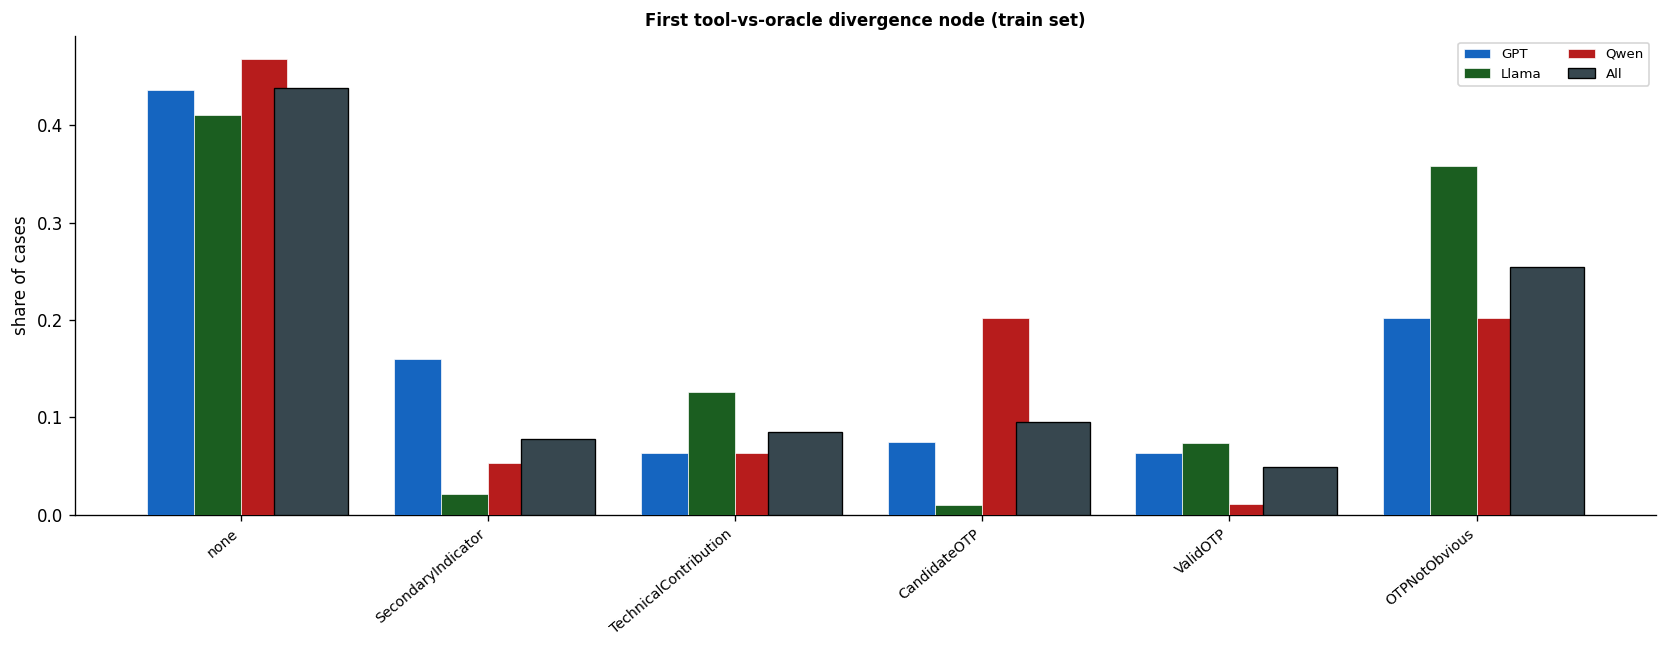

In [8]:
CANON = NO_SHORT + CRIT_YES

def caselevel_sets(sub):
    # (model,case) -> (accepted_set present in >=majority of runs, majority verdict)
    out = {}
    for (model, case), g in sub.groupby(['model', 'case']):
        cnt = Counter()
        for s in g['acc_set']:
            cnt.update(s)
        n = len(g)
        acc = {k for k, v in cnt.items() if v >= (n // 2 + 1)}
        maj = Counter(g['verdict']).most_common(1)[0][0]
        out[(model, case)] = (acc, maj)
    return out

tool_s   = caselevel_sets(df[df['mode'] == 'train_tool'])
oracle_s = caselevel_sets(df[df['mode'] == 'train_oracle'])
common = sorted(set(tool_s) & set(oracle_s))
print(f"train cases matched (model,case) in both tool & oracle: {len(common)}")

rows = []
for key in common:
    model, case = key
    t_acc, t_v = tool_s[key]
    o_acc, o_v = oracle_s[key]
    fd = 'none'
    for node in CANON:
        if (node in t_acc) != (node in o_acc):
            fd = node; break
    rows.append(dict(model=model, case=case, first_div=fd, flip=(t_v != o_v)))
dv = pd.DataFrame(rows)
print(f"\nverdict flip rate tool vs oracle: {dv['flip'].mean():.1%}")

fd_order = [n for n in ['none'] + CANON if n in dv['first_div'].unique()]
counts = {m: dv[dv['model'] == m]['first_div'].value_counts() for m in MODELS}
counts['All'] = dv['first_div'].value_counts()
x = np.arange(len(fd_order)); wsm, wagg = 0.19, 0.30
fig, ax = plt.subplots(figsize=(14, 5.5))
for gname in MODELS + ['All']:
    ser = counts[gname]
    denom = ser.sum() if ser.sum() else 1
    vals = [ser.get(n, 0) / denom for n in fd_order]
    if gname == 'All':
        ax.bar(x + 1.5*wsm, vals, wagg, label='All', color=AGG_COLOR, edgecolor='black', linewidth=0.8, zorder=3)
    else:
        off = {'GPT': -1.5*wsm, 'Llama': -0.5*wsm, 'Qwen': 0.5*wsm}[gname]
        ax.bar(x + off, vals, wsm, label=gname, color=MODEL_COLORS[gname], edgecolor='white', linewidth=0.4, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(fd_order, rotation=40, ha='right', fontsize=8.5)
ax.set_ylabel('share of cases'); ax.set_title('First tool-vs-oracle divergence node (train set)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig(FIGS / 'err4_divergence.png', bbox_inches='tight', dpi=150); plt.show()


## 5 — Sub-ADM 2 drill-down:  Qwen · cfg3 errors

Zoom into the **obviousness sub-model** for the model that leans on it hardest.
Sub-ADM 2 evaluates, per objective technical problem, whether the skilled person
*would have arrived* at the invention (→ obvious). Its root `ObjectiveProblemSolved`
is accepted (problem solved **non-obviously**) only when `WouldHaveArrived` is rejected
**and** a valid OTP formulation exists.

Sub-ADM 2 terminating nodes in the main ADM are: `OTPNotObvious` (valid OTP but declared
obvious), `ValidOTP` (invalid formulation), and `ObjectiveTechnicalProblem` (no OTP
established). `CandidateOTP` is a **main-ADM / Sub-ADM 1** node — it appears here for
context but is not highlighted as Sub-ADM 2.

In [ ]:
import sys
sys.path.insert(0, str(BASE / 'ADM'))
from inventive_step_ADM import sub_adm_2 as make_sub_adm_2
from collections import Counter
from matplotlib.patches import Patch

# Sub-ADM 2 terminating nodes in the main ADM (true Sub-ADM 2 failures)
SUB2_NODES = {'OTPNotObvious', 'ValidOTP', 'ObjectiveTechnicalProblem'}

q   = df[(df['mode'] == 'tool') & (df['model'] == 'Qwen') & (df['exp_cfg'] == 3)].copy()
err = q[~q['correct']]
s2  = err[err['term_node'].isin(SUB2_NODES)]
print(f"Qwen·cfg3:  runs={len(q)}  acc={q['correct'].mean():.3f}  errors={len(err)}")
print(f"Sub-ADM 2-localised errors: {len(s2)} ({len(s2)/len(err):.0%} of errors)  "
      f"direction: {dict(s2['err_type'].value_counts())}")

# ── Build sub-ADM 2 structure to extract rejection triggers ──────────────────
probe = make_sub_adm_2('_probe')

def _reject_triggers(adm):
    out = {}
    for parent, node in adm.nodes.items():
        if not node.acceptance:
            continue
        for cond in node.acceptance:
            tokens = cond.split()
            for i, tok in enumerate(tokens):
                if tok == 'reject' and i > 0:
                    out[tokens[i - 1]] = parent
    return out

reject_map = _reject_triggers(probe)
# → {'Hindsight': 'WellFormed', 'WouldHaveArrived': 'ObjectiveProblemSolved'}
# WouldModify and WouldAdapt both accept WouldHaveArrived → merged into one trigger

def first_trigger(case_set):
    if 'Hindsight' in case_set:
        return 'Hindsight'
    if 'WouldModify' in case_set or 'WouldAdapt' in case_set:
        return 'WouldHaveArrived'
    return 'no valid formulation'

def sub2_instances(row):
    return [s for s in row['subs'] if s['parent_fact'] == 'OTPNotObvious_sub_adm_instances']

# ── Per-problem obviousness outcome inside Sub-ADM 2 ──────────────────────────
def sub2_out(s):
    c = set(s['case'])
    if 'ObjectiveTechnicalProblemFormulation' not in c: return 'invalid formulation'
    if 'WouldHaveArrived' in c:                         return 'obvious (would-arrive)'
    if 'ObjectiveProblemSolved' in c:                   return 'non-obvious'
    return 'other'

q['n_prob'] = q['subs'].apply(lambda ss: sum(s['parent_fact'] == 'OTPNotObvious_sub_adm_instances' for s in ss))
reached = q[q['n_prob'] > 0]
print(f"\nreached Sub-ADM 2 (>=1 problem): {len(reached)} ({len(reached)/len(q):.0%})  "
      f"acc={reached['correct'].mean():.3f}  mean problems/run={reached['n_prob'].mean():.1f}")

per_prob = {}
for lab, sub in [('correct runs', reached[reached['correct']]), ('error runs', reached[~reached['correct']])]:
    c = Counter()
    for _, r in sub.iterrows():
        c.update(sub2_out(s) for s in sub2_instances(r))
    tot = sum(c.values())
    per_prob[lab] = {k: v / tot for k, v in c.items()}

# ── Rejection triggers across ALL sub-ADM 2 error instances ──────────────────
trigger_counts = Counter()
for _, row in s2.iterrows():
    for inst in sub2_instances(row):
        trigger_counts[first_trigger(set(inst['case']))] += 1

n_s2_inst = sum(trigger_counts.values())
print(f"\nSub-ADM 2 instances across s2 errors: {n_s2_inst}")
print("Rejection triggers (first accepted node that fires a reject condition):")
for k, v in trigger_counts.most_common():
    print(f"  {k:<25} {v:>4}  ({v/n_s2_inst:.0%})")

# ── Figure ────────────────────────────────────────────────────────────────────
QRED   = '#B71C1C'
LAYER_C = {'Main': '#78909C', 'Sub-ADM 1': '#1565C0', 'Sub-ADM 2': '#B71C1C'}

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(18, 5))

# A — error localisation, coloured by ADM layer
loc   = err['term_node'].value_counts()
loc   = loc[loc >= 10]
cols  = [LAYER_C.get(NODE_LAYER.get(n, 'Main'), '#78909C') for n in loc.index]
axA.bar(range(len(loc)), loc.values, color=cols, edgecolor='white')
axA.set_xticks(range(len(loc)))
axA.set_xticklabels(loc.index, rotation=40, ha='right', fontsize=8)
axA.set_ylabel('# error runs')
axA.set_title(f'Qwen·cfg3 error localisation\n({len(s2)/len(err):.0%} of errors in Sub-ADM 2, all FN)',
              fontsize=9.5, fontweight='bold')
axA.legend(handles=[Patch(facecolor=c, label=l) for l, c in LAYER_C.items()],
           fontsize=8, loc='upper right')
axA.spines[['top', 'right']].set_visible(False)

# B — per-problem outcome (correct vs error runs inside Sub-ADM 2)
cats = ['non-obvious', 'obvious (would-arrive)', 'invalid formulation']
xb = np.arange(len(cats)); wb = 0.38
for k, (lab, col) in enumerate([('correct runs', '#00897B'), ('error runs', QRED)]):
    vals = [per_prob[lab].get(c, 0) for c in cats]
    axB.bar(xb + (k - 0.5)*wb, vals, wb, label=lab, color=col, edgecolor='white')
axB.set_xticks(xb)
axB.set_xticklabels(['non-\nobvious', 'obvious\n(would-arrive)', 'invalid\nformulation'], fontsize=8)
axB.set_ylabel('share of problems')
axB.set_title('Per-problem obviousness verdict\n(inside Sub-ADM 2)', fontsize=9.5, fontweight='bold')
axB.legend(fontsize=8)
axB.spines[['top', 'right']].set_visible(False)

# C — rejection trigger (WouldModify + WouldAdapt merged → WouldHaveArrived)
TRIG_LBLS  = ['Hindsight', 'WouldHaveArrived', 'no valid formulation']
TRIG_DESCR = ['Hindsight\n(kills formulation)', 'WouldHaveArrived\n(modify or adapt)', 'No valid\nformulation']
TRIG_COLS  = ['#FF8F00', QRED, '#78909C']
tvals = [trigger_counts.get(t, 0) for t in TRIG_LBLS]

axC.bar(range(len(TRIG_LBLS)), tvals, color=TRIG_COLS, edgecolor='white')
axC.set_xticks(range(len(TRIG_LBLS)))
axC.set_xticklabels(TRIG_DESCR, fontsize=8)
axC.set_ylabel('# sub-problem instances')
axC.set_title('Rejection trigger in Sub-ADM 2 error instances\n(first accepted node firing a reject condition)',
              fontsize=9.5, fontweight='bold')
handles_c = [Patch(facecolor=TRIG_COLS[i], label=TRIG_DESCR[i].replace('\n', ' '))
             for i in range(len(TRIG_LBLS))]
axC.legend(handles=handles_c, fontsize=7.5, loc='upper right')
axC.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS / 'err5_subadm2_qwen_cfg3.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nReject map (from sub-ADM 2 structure):", reject_map)
print("\nPer-problem obviousness verdict (share):")
print(pd.DataFrame(per_prob).reindex(cats).fillna(0).round(3))
